In [1]:
from sage.all import *
from IPython.display import Image
import matplotlib.pyplot as plt

In [2]:
V_w,i_fb,V,R = var('V_w i_fb V R')

In [4]:
a = V_w == R * i_fb
b = i_fb == V / (680e3 + 15e3 + R)
c = 1.6 == i_fb * (15e3 + R)

In [5]:
solns = solve([a, b, c], [V_w, i_fb, R])[0]
solns

[V_w == -3/136*V + 139/85,
 i_fb == 1/680000*V - 1/425000,
 R == -5000*(15*V - 1112)/(5*V - 8)]

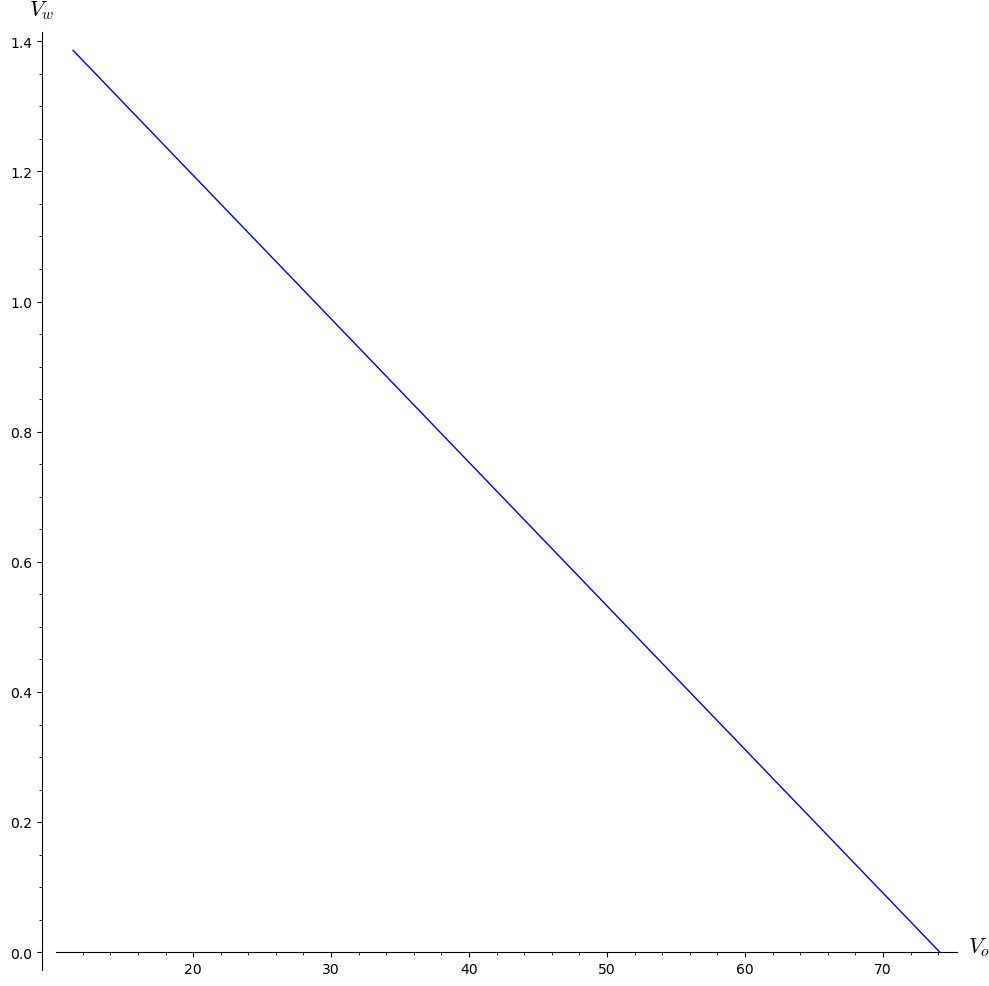

In [74]:
plot(solns[0].rhs(), (V, 11.3, 74.13), axes_labels=['$V_{o}$', '$V_w$'], figsize=(10, 10)).save('V_w_V.png')
Image('V_w_V.png')

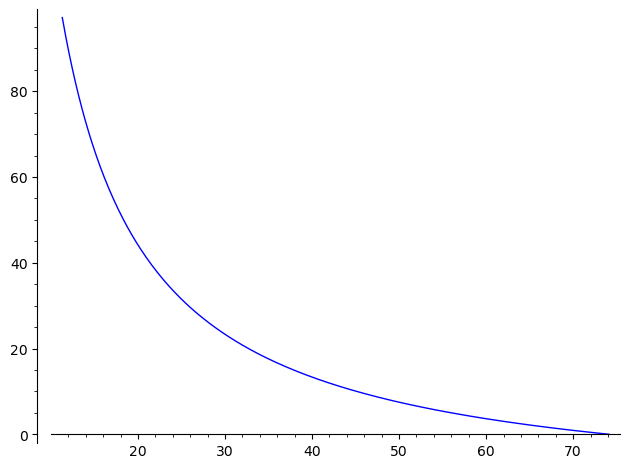

In [75]:
plot(solns[2].rhs()/1e3, (V, 11.3, 74.13)).save('R_V.png')
Image('R_V.png')

In [40]:
solve([a, b, c], V_w, i_fb, R)

[[V_w == -3/136*V + 1251/680,
  i_fb == 1/680000*V - 9/3400000,
  R == -15000*(5*V - 417)/(5*V - 9)]]

In [7]:
V_r = solve(solns[2], V)[0]
V_r

V == 8/5*(R + 695000)/(R + 15000)

In [9]:
V_r.subs(R = 50e3)

V == 18.338461538461537

In [4]:
# negative supply
a = V_w == R * i_fb
b = i_fb == V / (1.5e6 + 15e3 + R)
c = -0.8 == i_fb * (15e3 + R)

In [82]:
solns = solve([a, b, c], [V_w, i_fb, R])[0]
solns

[V_w == -1/100*V - 101/125,
 i_fb == 1/1500000*V + 1/1875000,
 R == -15000*(5*V + 404)/(5*V + 4)]

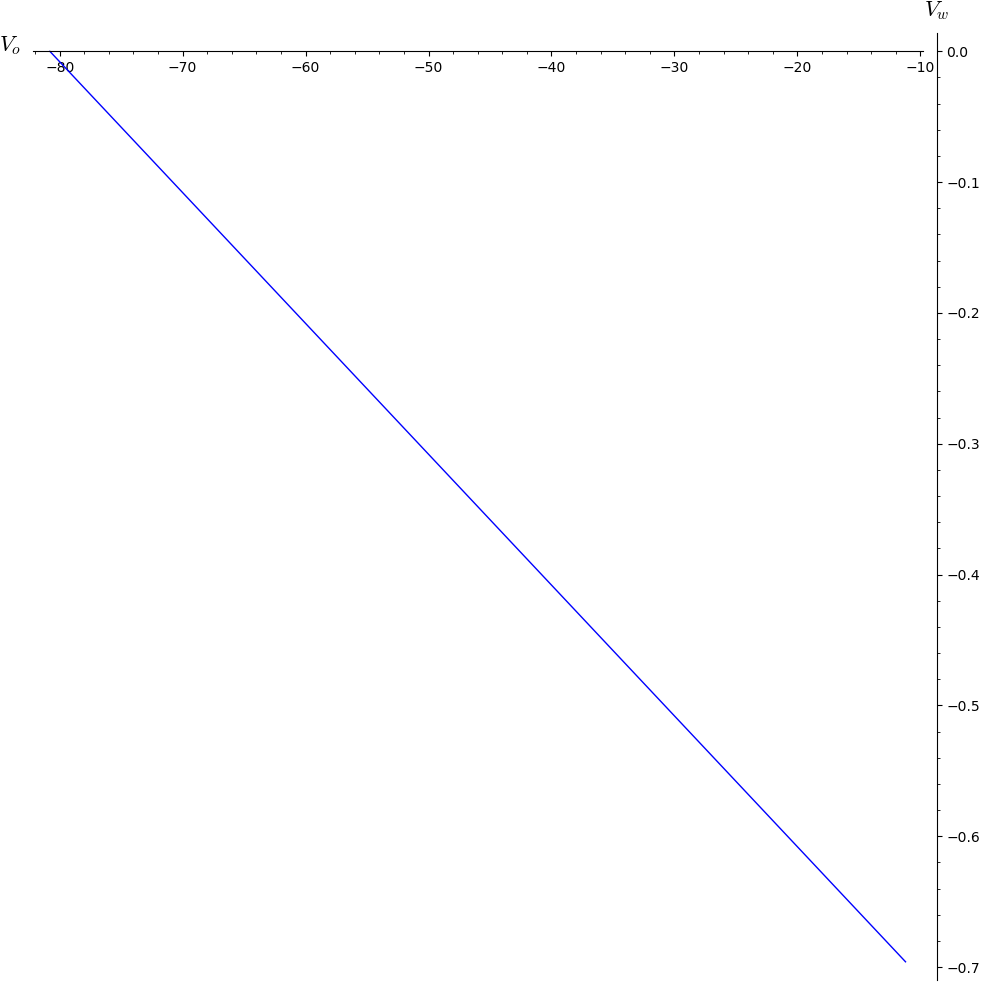

In [85]:
plot(solns[0].rhs(), (V, -80.8, -11.2), axes_labels=['$V_{o}$', '$V_w$'], figsize=(10, 10)).save('V_w_V.png')
Image('V_w_V.png')

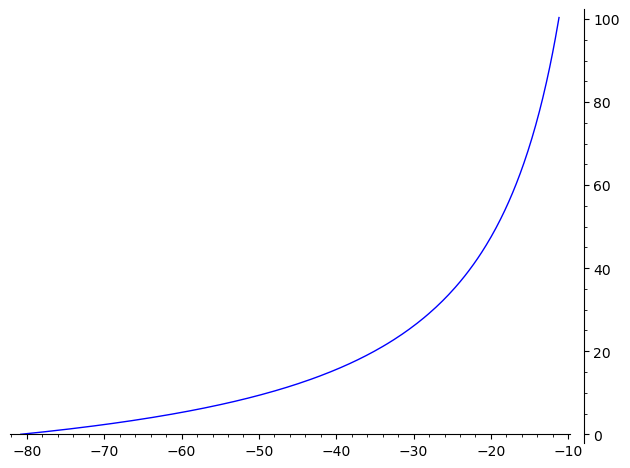

In [86]:
plot(solns[2].rhs()/1e3, (V, -80.8, -11.2)).save('R_V.png')
Image('R_V.png')

In [91]:
solns

[V_w == -1/100*V - 101/125,
 i_fb == 1/1500000*V + 1/1875000,
 R == -15000*(5*V + 404)/(5*V + 4)]

In [101]:
v_thres = solve(solns[0], V)[0].subs(V_w==-0.3)

In [111]:
R_thres = solns[2].subs(v_thres)

In [104]:
Vw_r = solns[0].subs(solve(solns[2], V)[0])

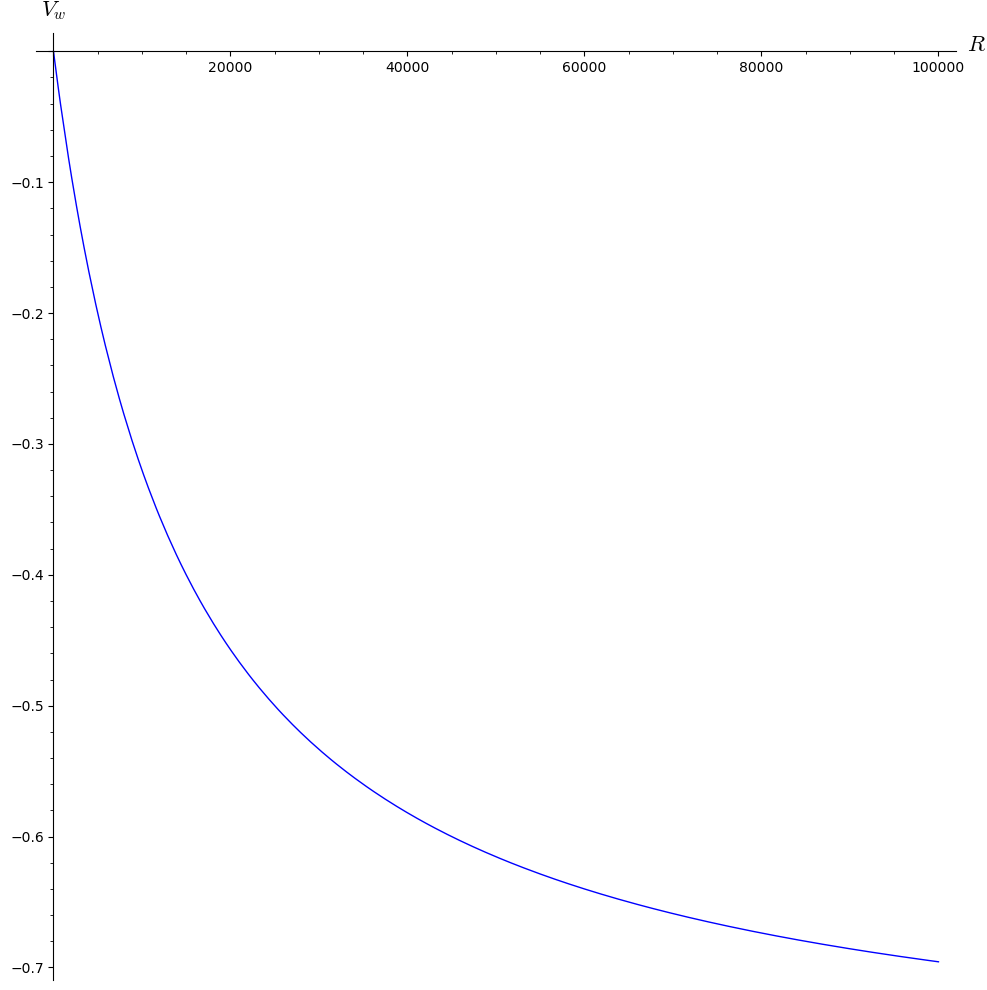

In [116]:
plot(Vw_r.rhs(), (V, 0, 100e3), axes_labels=['$R$', '$V_w$'], figsize=(10, 10)).save('Vw_r_V.png')
Image('Vw_r_V.png')

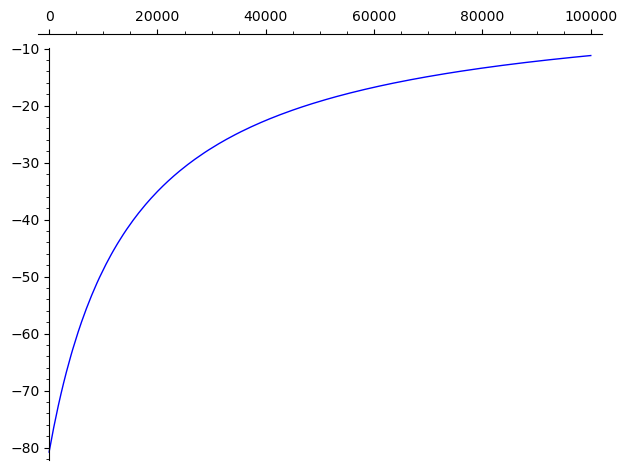

In [110]:
V_r = solve(solns[2], V)[0]
plot(V_r.rhs(), (R, 0, 100e3)).save('V_R.png')
Image('V_R.png')

In [1]:
V_r.subs(50e3)

NameError: name 'V_r' is not defined

In [65]:
# negative supply, but A tied to 3.3V
R1 = 383e3
# R1 = 4000e6
# R2 = 15e3
R2 = 20e3

a = V_w == R * i_fb + 3.3
b = i_fb == (V - 3.3) / (R1 + R2 + R)
c = -0.8 == i_fb * (R2 + R) + 3.3

In [66]:
solns = solve([a, b, c], [V_w, i_fb, R])[0]
solns

[V_w == -20/383*V - 1612/1915,
 i_fb == 1/383000*V + 1/478750,
 R == -500*(200*V + 15863)/(5*V + 4)]

In [67]:
Vr = solve(solns[2], V)[0]
Vr.subs(R=50e3)

V == -23.232857142857142

In [68]:
Vw_R = solns[0].subs(solve(solns[2], V)[0])
Vw_R.subs(R=0).rhs().n()

3.30000000000000

<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_141221/2131556030.py:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax3.set_ylabel("$I_{fb} (\mu A)$", color=color3)


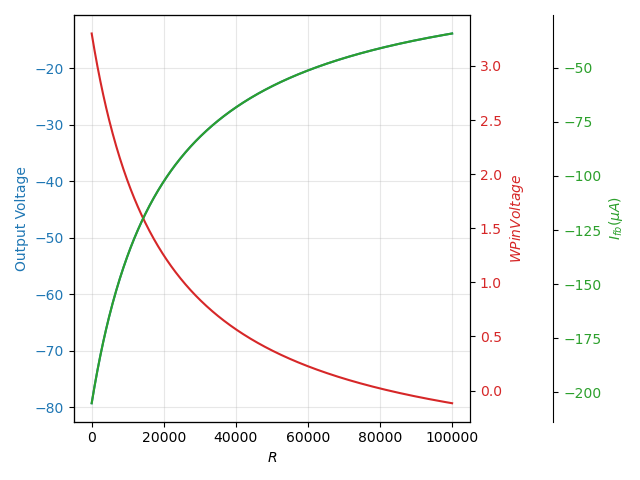

In [74]:
import matplotlib.pyplot as plt
import numpy as np

V_r = solve(solns[2], V)[0]
V_r_expr = V_r.rhs()
V_w_expr = solns[0].subs(V_r).rhs()
i_fb_expr = solns[1].subs(V_r).rhs()

R_vals = np.linspace(0, 100e3, 500)
V_r_vals = [float(V_r_expr.subs(R=r)) for r in R_vals]
V_w_vals = [float(V_w_expr.subs(R=r)) for r in R_vals]
i_fb_vals = [float(i_fb_expr.subs(R=r)) * 1e6 for r in R_vals]

fig, ax1 = plt.subplots()

color1 = "tab:blue"
ax1.set_xlabel("$R$")
ax1.set_ylabel("Output Voltage", color=color1)
ax1.plot(R_vals, V_r_vals, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("$W Pin Voltage$", color=color2)
ax2.plot(R_vals, V_w_vals, color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
color3 = "tab:green"
ax3.set_ylabel("$I_{fb} (\mu A)$", color=color3)
ax3.plot(R_vals, i_fb_vals, color=color3)
ax3.tick_params(axis="y", labelcolor=color3)

fig.tight_layout()
fig.savefig("Vw_R.png")
plt.close(fig)
Image("Vw_R.png")

In [25]:
# Calculate fixed resistor
R3 = 15e3

#a = V_w == R * i_fb + 3.3
b = i_fb == (V) / (R1 + R3)
c = -0.8 == i_fb * R3
soln = solve([b, c])[0]
soln[0].rhs().n()

-21.2266666666667

-5.305882352941176

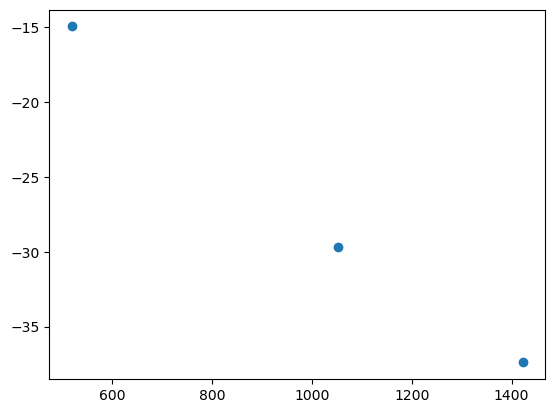

In [39]:
# neg ADC debugging
Vout = [-14.97, -29.7, -37.39]
Adc = [0x207, 0x41d, 0x58e]

plt.scatter(Adc, Vout)